# Interact with Jupyter in `serc` just like a local machine

In this demo, we'll show you how Jupyter Lab can be used in an Open On Demand session within Sherlock similarly to how you might use the Jupyter ecosystem on your local machine. 

Today's Learning Goals:
> 1. Import software modules in Sherlock
> 2. Develop a test analysis pipeline in Python
> 3. Transfer code pipeline into a script file
> 4. Write an `sbatch` file to run the scripted pipeline
> 5. Schedule your first `serc` batch job with Slurm


### Accessing Sherlock's Modules and Importing Python Packages
In this tutorial, we'll show you how Jupyter Lab can be used in an [Open On Demand session](https://ondemand.sherlock.stanford.edu/pun/sys/dashboard/batch_connect/sessions) within `serc` similarly to how you might use the Jupyter ecosystem on your local machine. When using `serc` on Sherlock, there are some software packages that you don't have to worry about updating and installing onto the HPC system. Instead, Sherlock keeps a [list](https://www.sherlock.stanford.edu/docs/software/list/) of available pre-installed packages that you can import as modules. To deploy a module in your interactive session, add your preselected list of modules to the "Additional Modules section" when you are queuing up your On Demand session. If you want to deploy an additional module once your session has already started, open a Terminal window and type `module load <module-name>`.

Once the appropriate modules are loaded, either before the session or by using Terminal within your session, you can import the packages that you need.

In [1]:
%%bash
module purge
module load py-numpy/1.26.3_py312
module load py-pandas/2.2.1_py312
module load viz
module load py-matplotlib/3.8.3_py312
module load py-seaborn/0.13.2_py312

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) devel   2) math


Now that your modules are loaded, we can import Python libraries the same way that we would on a local machine:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Analyzing Temperature Distribution by Region using `pandas`

Now we'll simulate a year of data from a fictional weather monitoring station using `numpy`.

In [3]:
np.random.seed(42)
n = 365

In [4]:
# Simulate regions
regions = np.random.choice(['Coastal', 'Inland', 'Mountain'], size=n)

# Temperature (°C)
temperature = np.random.normal(loc=15, scale=5, size=n)
temperature += (regions == 'Coastal') * 2
temperature += (regions == 'Mountain') * -5

# Precipitation (mm)
precipitation = np.random.exponential(scale=3, size=n)
precipitation += (regions == 'Mountain') * 1.5

# Wind Speed (km/h)
wind_speed = np.random.normal(loc=10, scale=2, size=n)
wind_speed += (regions == 'Coastal') * 3

We can put our data in a dataframe using `pandas`.

In [5]:
df = pd.DataFrame({
    'Region': regions,
    'Temperature_C': temperature,
    'Precipitation_mm': precipitation,
    'WindSpeed_kmh': wind_speed,
    'DayOfYear': np.arange(1, n + 1)
})

Which we can visualize directly in the notebook, the same way that you might on your laptop:

In [6]:
df.head(5)

,Region,Temperature_C,Precipitation_mm,WindSpeed_kmh,DayOfYear
0,Mountain,5.580713,2.833384,14.150802,1
1,Coastal,17.768626,6.291608,12.008062,2
2,Mountain,10.291044,2.994938,9.663770,3
3,Mountain,4.285149,6.588248,9.253201,4
4,Coastal,18.788937,1.734825,10.652860,5


`pandas` also allows us to look at the summary stats, so we can get a better idea of the distribution of each of our variables.

In [7]:
summary = df.describe()
print("Summary statistics:\n")
print(summary)

Summary statistics:

       Temperature_C  Precipitation_mm  WindSpeed_kmh   DayOfYear
count     365.000000        365.000000     365.000000  365.000000
mean       13.915750          3.484146      11.112359  183.000000
std         5.718611          3.006421       2.319492  105.510663
min        -1.206337          0.013928       3.038382    1.000000
25%        10.086001          1.343430       9.586866   92.000000
50%        14.053176          2.714458      11.061601  183.000000
75%        17.852993          4.808630      12.647750  274.000000
max        29.263657         18.804245      18.930021  365.000000


We can also use `pandas` to probe a specific stat, like mean temperature by region.

In [8]:
mean_temp_by_region = df.groupby('Region')['Temperature_C'].mean()
print("\nMean Temperature by Region:")
print(mean_temp_by_region)


Mean Temperature by Region:
Region
Coastal     16.598448
Inland      15.305114
Mountain    10.028910
Name: Temperature_C, dtype: float64


We can take a closer look at the temperature distribution for each region using `seaborn` and `matplotlib`. The interactive session allows us to see this visualization in-line even though we're running this on an HPC node. We can also save this figure directly to Oak from Sherlock.

*Note*: When working with many files on `serc`, it's a better idea to save output files to directly to `/scratch/` rather than Oak, because of I/O limitations. `/scratch/` deletes files that haven't been interacted with in the last 90 days, so it's a good idea to back up anything that you need to persist on Oak. 

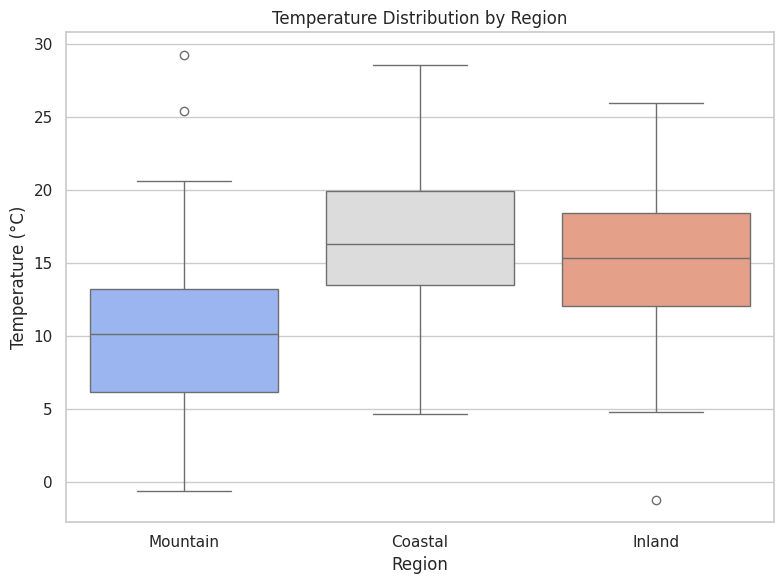

In [9]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x='Region', y='Temperature_C', data=df, 
            hue='Region', palette='coolwarm', legend=False)
plt.title('Temperature Distribution by Region')
plt.ylabel('Temperature (°C)')
plt.tight_layout()

plt.savefig('../figs/temperature_dists.png')

Finally, once we're ready, we can save a csv of the summary statistics of all the weather variables directly from our interactive session.

In [10]:
summary.to_csv('../data/weather_stats.csv')

## My code works! What happens when I want to scale up?

Congratulations on building a Python pipeline that achieves your analysis goals! Now that you have a pipeline that works end-to-end, let's get it set up to run as a batch job. This is going to require three steps from our learning goals above. Let's walk through them.

### Transfer your Pipeline into a Script File

For the sake of time, we've moved this analysis over into a script file located at `python_scripts/analysis_pipeline.py` within the [tutorial repo](https://github.com/stanford-sdss/postdoc_onboarding). Please open this file and update the path in `WORK_DIR` to your working directory. Let's quickly go over some of the components that we have changed as we transition from development (in our interactive session) to training (in our batch job).

First, for scripting purposes, we write our entire pipeline into a `main()` function that can be called at runtime. We've written it to make any hyperparameters easily updatable within the final function call.

Because we are shifting our pipeline out of development mode into the training stage, we are moving over to a batch job. Moving to a batch job also allows us to request a longer runtime and more resources within the Community Guidelines for `serc`.

### Write an `sbatch` Script to run the Scripted Pipeline

Now that we have a script for our Python pipeline, we need to instruct Sherlock to schedule the hardware specs that we need for our job and to run our script on this hardware. We do this using an `sbatch` file, which is a shell script that tells the system what resources we are requesting for how long and which commands to run. In this tutorial, we have provided you with a sample `sbatch` file, located at `sbatch_scripts/run_analysis.submit` in the [tutorial repo](https://github.com/stanford-sdss/postdoc_onboarding). Please open this file and update your SUnet ID and the path.

Let's walk through components of the `sbatch` file in parts. On Sherlock, we use a job scheduler called [Slurm](https://slurm.schedmd.com/), and we use the first section of our `sbatch` file to provide directives to Slurm. Slurm has excellent documentation on these flags, and we'll only go through a subset of options today, but you can find their docs [here](https://slurm.schedmd.com/sbatch.html).

One required flag for working on `serc` specifically is the `partition` flag which directs Slurm to schedule our job on the nodes dedicated to the `serc` partition.
```bash
#SBATCH --partition=serc  
```

We'll do a quick review of some other flags here.
```bash
#SBATCH --nodes=1                            
#SBATCH --ntasks=1                           
#SBATCH --cpus-per-task=8                                                           
#SBATCH --time=01:00:00                      
```

`nodes=1`: Many jobs only need 1 compute node, and it's a good idea to specify this when you do only need one node, since computing across multiple nodes requires that your code is prepared to distribute your compute in a multi-node fashion. 

`ntasks=1`: This controls the number of processes that we'll be spawning. This can change depending on your parallelization setup.

`cpus-per-task=8`: We also define how many CPUs we'll be booking on the node. How many CPUs you need will depend on your data, CPU compute, and memory needs. 

`time=01:00:00`: We use this flag to specify our runtime, and it follows the HH:MM:SS convention. It's helpful to run a small test job to calculate how much total time you might need and then to add on a 15% safety margin. `serc` has a runtime limitation of 7 days when running a batch job, but we request that you use the minimal amount of time that you need for fair share. Helpful tip! Include checkpointing inside your training pipeline so that you don't lose any progress if your runtime ends before your code is finished running.